In [1]:
import pandas as pd
import glob

In [2]:
# folder path
path = r"D:\egg_price_procject\output\main_data\*.csv"
# get all csv files
files = glob.glob(path)

In [3]:
# getting all cities data in dic all_data
all_data = {}
for file in files:
    name = file.split("\\")[-1].split(".")[0]
    file_name = name
    name = pd.read_csv(file)
    all_data[file_name] = name
print(all_data.keys())

dict_keys(['Ajmer_main_data', 'Barwala_main_data', 'Delhi_main_data', 'Hyderabad_main_data', 'Indore_main_data', 'Varanasi_main_data'])


In [4]:
all_data['Barwala_main_data'].head(20)

,Category,City,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,...,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,festival_name,is_festival
0,NECC SUGGESTED EGG PRICES,Barwala,375.0,12,5,2016,2016-05-12,NaN,0,NaN,...,2,0,NaN,NaN,NaN,2016-05-12,37.3,0.0,NaN,NaN
1,NECC SUGGESTED EGG PRICES,Barwala,375.0,13,5,2016,2016-05-13,0.000000,0,375.0,...,2,0,NaN,NaN,NaN,2016-05-13,39.5,0.5,NaN,NaN
2,NECC SUGGESTED EGG PRICES,Barwala,378.0,14,5,2016,2016-05-14,0.800000,0,375.0,...,2,1,NaN,NaN,NaN,2016-05-14,40.9,0.0,NaN,NaN
3,NECC SUGGESTED EGG PRICES,Barwala,378.0,15,5,2016,2016-05-15,0.000000,0,378.0,...,2,1,375.0,NaN,NaN,2016-05-15,41.1,0.0,NaN,NaN
4,NECC SUGGESTED EGG PRICES,Barwala,378.0,16,5,2016,2016-05-16,0.000000,0,378.0,...,2,0,375.0,NaN,NaN,2016-05-16,41.3,0.2,NaN,NaN
5,NECC SUGGESTED EGG PRICES,Barwala,378.0,17,5,2016,2016-05-17,0.000000,0,378.0,...,2,0,378.0,NaN,NaN,2016-05-17,41.7,0.0,NaN,NaN
6,NECC SUGGESTED EGG PRICES,Barwala,361.0,18,5,2016,2016-05-18,-4.497354,-2,378.0,...,2,0,378.0,NaN,NaN,2016-05-18,42.8,0.0,NaN,NaN
7,NECC SUGGESTED EGG PRICES,Barwala,350.0,19,5,2016,2016-05-19,-3.047091,-2,361.0,...,2,0,378.0,NaN,NaN,2016-05-19,41.5,0.5,NaN,NaN
8,NECC SUGGESTED EGG PRICES,Barwala,350.0,20,5,2016,2016-05-20,0.000000,0,350.0,...,2,0,378.0,NaN,NaN,2016-05-20,41.3,0.0,NaN,NaN
9,NECC SUGGESTED EGG PRICES,Barwala,350.0,21,5,2016,2016-05-21,0.000000,0,350.0,...,2,1,361.0,NaN,NaN,2016-05-21,41.1,0.0,Buddha Purnima,1.0


### FOR NOW I AM JUST GETTING BARWALA DATA

In [5]:
df = all_data['Barwala_main_data']

In [6]:
df.head()

,Category,City,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,...,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,festival_name,is_festival
0,NECC SUGGESTED EGG PRICES,Barwala,375.0,12,5,2016,2016-05-12,NaN,0,NaN,...,2,0,NaN,NaN,NaN,2016-05-12,37.3,0.0,NaN,NaN
1,NECC SUGGESTED EGG PRICES,Barwala,375.0,13,5,2016,2016-05-13,0.0,0,375.0,...,2,0,NaN,NaN,NaN,2016-05-13,39.5,0.5,NaN,NaN
2,NECC SUGGESTED EGG PRICES,Barwala,378.0,14,5,2016,2016-05-14,0.8,0,375.0,...,2,1,NaN,NaN,NaN,2016-05-14,40.9,0.0,NaN,NaN
3,NECC SUGGESTED EGG PRICES,Barwala,378.0,15,5,2016,2016-05-15,0.0,0,378.0,...,2,1,375.0,NaN,NaN,2016-05-15,41.1,0.0,NaN,NaN
4,NECC SUGGESTED EGG PRICES,Barwala,378.0,16,5,2016,2016-05-16,0.0,0,378.0,...,2,0,375.0,NaN,NaN,2016-05-16,41.3,0.2,NaN,NaN


In [7]:
df.shape

(3616, 27)

In [8]:
df.columns

Index(['Category', 'City', 'Price', 'Day', 'Month', 'Year', 'Date',
       'daily_change_pct', 'market_rating', 'lag_1', 'lag_7', 'rolling_mean_7',
       'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'dayofweek',
       'weekofyear', 'quarter', 'is_weekend', 'lag_3', 'lag_14', 'lag_30',
       'date', 'tmax', 'prcp', 'festival_name', 'is_festival'],
      dtype='object')

In [9]:
df = df.drop(['festival_name','City','Category'], axis=1)
df['is_festival'] = df['is_festival'].notna().astype(int)

In [10]:
# df = df.dropna()

In [11]:
df.head()

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
0,375.0,12,5,2016,2016-05-12,NaN,0,NaN,NaN,NaN,...,19,2,0,NaN,NaN,NaN,2016-05-12,37.3,0.0,0
1,375.0,13,5,2016,2016-05-13,0.0,0,375.0,NaN,NaN,...,19,2,0,NaN,NaN,NaN,2016-05-13,39.5,0.5,0
2,378.0,14,5,2016,2016-05-14,0.8,0,375.0,NaN,NaN,...,19,2,1,NaN,NaN,NaN,2016-05-14,40.9,0.0,0
3,378.0,15,5,2016,2016-05-15,0.0,0,378.0,NaN,NaN,...,19,2,1,375.0,NaN,NaN,2016-05-15,41.1,0.0,0
4,378.0,16,5,2016,2016-05-16,0.0,0,378.0,NaN,NaN,...,20,2,0,375.0,NaN,NaN,2016-05-16,41.3,0.2,0


In [12]:
df.shape

(3616, 24)

In [13]:
df['is_festival'].unique()

array([0, 1])

In [14]:
df['is_festival'].value_counts()

0    3457
1     159
Name: is_festival, dtype: int64

In [15]:
df.shape

(3616, 24)

In [16]:
df.isnull().sum()

Price                0
Day                  0
Month                0
Year                 0
Date                 0
daily_change_pct     1
market_rating        0
lag_1                1
lag_7                7
rolling_mean_7       7
rolling_mean_14     14
rolling_mean_30     30
rolling_std_7        7
dayofweek            0
weekofyear           0
quarter              0
is_weekend           0
lag_3                3
lag_14              14
lag_30              30
date                 0
tmax                 0
prcp                 0
is_festival          0
dtype: int64

In [17]:
df =df.dropna()

In [18]:
df.shape

(3586, 24)

In [19]:
df.head()

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
30,360.0,11,6,2016,2016-06-11,0.000000,0,360.0,352.0,355.714286,...,23,2,1,358.0,330.0,375.0,2016-06-11,37.8,0.5,0
31,360.0,12,6,2016,2016-06-12,0.000000,0,360.0,352.0,356.857143,...,23,2,1,358.0,333.0,375.0,2016-06-12,38.8,0.0,0
32,367.0,13,6,2016,2016-06-13,1.944444,1,360.0,354.0,358.000000,...,24,2,0,360.0,339.0,378.0,2016-06-13,40.1,0.3,0
33,373.0,14,6,2016,2016-06-14,1.634877,1,367.0,356.0,359.857143,...,24,2,0,360.0,348.0,378.0,2016-06-14,37.5,2.0,0
34,377.0,15,6,2016,2016-06-15,1.072386,1,373.0,358.0,362.285714,...,24,2,0,360.0,348.0,378.0,2016-06-15,32.2,11.5,0


In [20]:
df.head()

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
30,360.0,11,6,2016,2016-06-11,0.000000,0,360.0,352.0,355.714286,...,23,2,1,358.0,330.0,375.0,2016-06-11,37.8,0.5,0
31,360.0,12,6,2016,2016-06-12,0.000000,0,360.0,352.0,356.857143,...,23,2,1,358.0,333.0,375.0,2016-06-12,38.8,0.0,0
32,367.0,13,6,2016,2016-06-13,1.944444,1,360.0,354.0,358.000000,...,24,2,0,360.0,339.0,378.0,2016-06-13,40.1,0.3,0
33,373.0,14,6,2016,2016-06-14,1.634877,1,367.0,356.0,359.857143,...,24,2,0,360.0,348.0,378.0,2016-06-14,37.5,2.0,0
34,377.0,15,6,2016,2016-06-15,1.072386,1,373.0,358.0,362.285714,...,24,2,0,360.0,348.0,378.0,2016-06-15,32.2,11.5,0


In [21]:
df.dtypes

Price               float64
Day                   int64
Month                 int64
Year                  int64
Date                 object
daily_change_pct    float64
market_rating         int64
lag_1               float64
lag_7               float64
rolling_mean_7      float64
rolling_mean_14     float64
rolling_mean_30     float64
rolling_std_7       float64
dayofweek             int64
weekofyear            int64
quarter               int64
is_weekend            int64
lag_3               float64
lag_14              float64
lag_30              float64
date                 object
tmax                float64
prcp                float64
is_festival           int32
dtype: object

In [22]:
df.Date.max()

'2026-05-12'

In [23]:
pd.set_option('display.max_columns', None)

In [24]:
df.head()

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,dayofweek,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
30,360.0,11,6,2016,2016-06-11,0.000000,0,360.0,352.0,355.714286,348.857143,355.600000,3.147183,5,23,2,1,358.0,330.0,375.0,2016-06-11,37.8,0.5,0
31,360.0,12,6,2016,2016-06-12,0.000000,0,360.0,352.0,356.857143,351.000000,355.100000,3.023716,6,23,2,1,358.0,333.0,375.0,2016-06-12,38.8,0.0,0
32,367.0,13,6,2016,2016-06-13,1.944444,1,360.0,354.0,358.000000,352.928571,354.600000,2.309401,0,24,2,0,360.0,339.0,378.0,2016-06-13,40.1,0.3,0
33,373.0,14,6,2016,2016-06-14,1.634877,1,367.0,356.0,359.857143,354.928571,354.233333,3.484660,1,24,2,0,360.0,348.0,378.0,2016-06-14,37.5,2.0,0
34,377.0,15,6,2016,2016-06-15,1.072386,1,373.0,358.0,362.285714,356.714286,354.066667,5.618846,2,24,2,0,360.0,348.0,378.0,2016-06-15,32.2,11.5,0


In [25]:
features = ["Price","market_rating","lag_1","lag_3","lag_7","lag_14","lag_30","rolling_mean_7"
            ,"rolling_mean_14","rolling_mean_30","rolling_std_7","tmax","prcp","dayofweek","weekofyear",
            "quarter","is_weekend","is_festival"]

In [26]:
data_ = df.sort_values('Date')
data_.tail(20)

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,dayofweek,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
3596,503.0,23,4,2026,2026-04-23,0.801603,0,499.0,495.0,489.857143,495.500000,455.033333,5.014265,3,17,2,0,487.0,459.0,392.0,2026-04-23,38.2,0.0,0
3597,503.0,24,4,2026,2026-04-24,0.000000,0,503.0,487.0,491.000000,498.642857,458.733333,6.928203,4,17,2,0,487.0,466.0,392.0,2026-04-24,39.0,0.0,0
3598,503.0,25,4,2026,2026-04-25,0.000000,0,503.0,487.0,493.285714,501.285714,462.433333,7.952238,5,17,2,1,499.0,478.0,392.0,2026-04-25,39.3,0.0,0
3599,475.0,26,4,2026,2026-04-26,-5.566600,-3,503.0,487.0,495.571429,503.071429,466.133333,8.141604,6,17,2,1,503.0,515.0,392.0,2026-04-26,39.0,0.0,0
3600,475.0,27,4,2026,2026-04-27,0.000000,0,475.0,487.0,493.857143,500.214286,468.900000,11.006492,0,18,2,0,503.0,530.0,396.0,2026-04-27,38.3,0.0,0
3601,483.0,28,4,2026,2026-04-28,1.684211,1,475.0,487.0,492.142857,496.285714,471.533333,13.005493,1,18,2,0,503.0,530.0,401.0,2026-04-28,34.2,0.3,0
3602,491.0,29,4,2026,2026-04-29,1.656315,1,483.0,499.0,491.571429,492.928571,474.266667,13.352367,2,18,2,0,475.0,530.0,415.0,2026-04-29,34.0,1.8,0
3603,491.0,30,4,2026,2026-04-30,0.000000,0,491.0,503.0,490.428571,490.142857,476.800000,12.946777,3,18,2,0,475.0,495.0,430.0,2026-04-30,34.8,0.4,0
3604,491.0,1,5,2026,2026-05-01,0.000000,0,491.0,503.0,488.714286,489.857143,478.833333,11.743286,4,18,2,0,483.0,487.0,433.0,2026-05-01,33.4,0.0,1
3605,491.0,2,5,2026,2026-05-02,0.000000,0,491.0,503.0,487.000000,490.142857,480.766667,10.066446,5,18,2,1,491.0,487.0,433.0,2026-05-02,34.0,0.0,0


In [27]:
df[df['Date']==df.Date.max()][features]

,Price,market_rating,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,tmax,prcp,dayofweek,weekofyear,quarter,is_weekend,is_festival
3615,518.0,0,518.0,501.0,491.0,483.0,515.0,499.714286,494.785714,497.333333,11.161157,33.2,0.1,1,20,2,0,0


In [28]:
df.Date.max()

'2026-05-12'

In [29]:
split_year = 2024

In [30]:
train_data = df[df['Year']<=split_year]

In [31]:
test_data = df[df['Year'] >split_year]

In [32]:
df.dtypes

Price               float64
Day                   int64
Month                 int64
Year                  int64
Date                 object
daily_change_pct    float64
market_rating         int64
lag_1               float64
lag_7               float64
rolling_mean_7      float64
rolling_mean_14     float64
rolling_mean_30     float64
rolling_std_7       float64
dayofweek             int64
weekofyear            int64
quarter               int64
is_weekend            int64
lag_3               float64
lag_14              float64
lag_30              float64
date                 object
tmax                float64
prcp                float64
is_festival           int32
dtype: object

In [33]:
df_rec = df[df['Year'] > split_year]
recursicce_test_data = df_rec[df_rec['Date']==df_rec.Date.min()]
recursicce_test_data.head()

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,dayofweek,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
3119,574.0,1,1,2025,2025-01-01,0.34965,0,572.0,616.0,589.285714,598.5,612.166667,16.809861,2,1,1,0,575.0,607.0,624.0,2025-01-01,16.8,0.0,0


In [34]:
test_data.Date.max()

'2026-05-12'

In [35]:
train_data.shape

(3089, 24)

In [36]:
train_data.Date.max()

'2024-12-31'

In [37]:
test_data.sort_values('Date').tail()

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,dayofweek,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
3611,494.0,8,5,2026,2026-05-08,0.610998,0,491.0,491.0,491.000000,489.857143,491.766667,0.000000,4,19,2,0,491.0,503.0,455.0,2026-05-08,31.9,1.8,0
3612,501.0,9,5,2026,2026-05-09,1.417004,1,494.0,491.0,491.428571,489.214286,493.066667,1.133893,5,19,2,1,491.0,503.0,459.0,2026-05-09,35.0,0.0,0
3613,512.0,10,5,2026,2026-05-10,2.195609,1,501.0,491.0,492.857143,489.071429,494.466667,3.760699,6,19,2,1,491.0,475.0,466.0,2026-05-10,33.8,0.0,0
3614,518.0,11,5,2026,2026-05-11,1.171875,1,512.0,491.0,495.857143,491.714286,496.000000,8.008924,0,20,2,0,494.0,475.0,478.0,2026-05-11,33.0,1.7,0
3615,518.0,12,5,2026,2026-05-12,0.000000,0,518.0,491.0,499.714286,494.785714,497.333333,11.161157,1,20,2,0,501.0,483.0,515.0,2026-05-12,33.2,0.1,0


In [38]:
features = ["Price","market_rating","lag_1","lag_3","lag_7","lag_14","lag_30","rolling_mean_7"
            ,"rolling_mean_14","rolling_mean_30","rolling_std_7","tmax","prcp","dayofweek","weekofyear",
            "quarter","is_weekend","is_festival"]

In [39]:
main_test_data = test_data[features]
main_train_data = train_data[features]

In [40]:
main_test_data.shape

(497, 18)

In [41]:
main_train_data.shape

(3089, 18)

In [42]:
main_train_data.head()

,Price,market_rating,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,tmax,prcp,dayofweek,weekofyear,quarter,is_weekend,is_festival
30,360.0,0,360.0,358.0,352.0,330.0,375.0,355.714286,348.857143,355.600000,3.147183,37.8,0.5,5,23,2,1,0
31,360.0,0,360.0,358.0,352.0,333.0,375.0,356.857143,351.000000,355.100000,3.023716,38.8,0.0,6,23,2,1,0
32,367.0,1,360.0,360.0,354.0,339.0,378.0,358.000000,352.928571,354.600000,2.309401,40.1,0.3,0,24,2,0,0
33,373.0,1,367.0,360.0,356.0,348.0,378.0,359.857143,354.928571,354.233333,3.484660,37.5,2.0,1,24,2,0,0
34,377.0,1,373.0,360.0,358.0,348.0,378.0,362.285714,356.714286,354.066667,5.618846,32.2,11.5,2,24,2,0,0


In [43]:
main_train_data.head()

,Price,market_rating,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,tmax,prcp,dayofweek,weekofyear,quarter,is_weekend,is_festival
30,360.0,0,360.0,358.0,352.0,330.0,375.0,355.714286,348.857143,355.600000,3.147183,37.8,0.5,5,23,2,1,0
31,360.0,0,360.0,358.0,352.0,333.0,375.0,356.857143,351.000000,355.100000,3.023716,38.8,0.0,6,23,2,1,0
32,367.0,1,360.0,360.0,354.0,339.0,378.0,358.000000,352.928571,354.600000,2.309401,40.1,0.3,0,24,2,0,0
33,373.0,1,367.0,360.0,356.0,348.0,378.0,359.857143,354.928571,354.233333,3.484660,37.5,2.0,1,24,2,0,0
34,377.0,1,373.0,360.0,358.0,348.0,378.0,362.285714,356.714286,354.066667,5.618846,32.2,11.5,2,24,2,0,0


In [44]:
target = "Price"
features_train = ["market_rating","lag_1","lag_3","lag_7","lag_14","lag_30","rolling_mean_7"
            ,"rolling_mean_14","rolling_mean_30","rolling_std_7","tmax","prcp","dayofweek","weekofyear",
            "quarter","is_weekend","is_festival"]
len(features_train)

17

In [45]:
x_train = main_train_data[features_train]
y_train = main_train_data["Price"]

In [46]:
x_test = main_test_data[features_train]
y_test = main_test_data['Price']

In [47]:
df_rec = df[df['Year'] > split_year]
recursicce_test_data = df_rec[df_rec['Date']==df_rec.Date.min()]
recursicce_test_data = recursicce_test_data[features_train].reset_index(drop = True)
value = recursicce_test_data.iloc[0].to_list()

In [48]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost is required for this notebook. Install it with: pip install xgboost"
    ) from exc


In [49]:
# Tune hyperparameters with time-series aware cross-validation.
# RandomizedSearchCV is faster than a full grid while still testing strong parameter combinations.
tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_distributions = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.05, 0.1],
    "reg_lambda": [0.5, 1, 2, 5],
    "gamma": [0, 0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train, y_train)

best_model = search.best_estimator_
print("Best CV RMSE:", round(-search.best_score_, 3))
print("Best parameters:")
search.best_params_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV RMSE: 7.799
Best parameters:


{'subsample': 1.0,
 'reg_lambda': 1,
 'reg_alpha': 0.01,
 'n_estimators': 500,
 'min_child_weight': 1,
 'max_depth': 3,
 'learning_rate': 0.08,
 'gamma': 0.05,
 'colsample_bytree': 1.0}

recursive 

In [50]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio


# ---------------------------------------------------
# OPEN PLOTLY CHARTS IN BROWSER
# ---------------------------------------------------
pio.renderers.default = "browser"


def plot_comparison_chart(
    x_dates,
    list_1,
    list_2,
    label_1="Series 1",
    label_2="Series 2",
    title="Comparison Chart"
):
    """
    Universal Plotly comparison chart

    Parameters
    ----------
    x_dates : list / pd.Series
        Dates or x-axis values

    list_1 : list / pd.Series
        First line values

    list_2 : list / pd.Series
        Second line values

    label_1 : str
        Name of first line

    label_2 : str
        Name of second line

    title : str
        Chart title

    Returns
    -------
    Plotly Figure
    """

    # ---------------------------------------------------
    # CONVERT EVERYTHING TO LIST
    # ---------------------------------------------------
    # This avoids pandas index alignment problems
    # ---------------------------------------------------
    x_dates = list(x_dates)

    list_1 = list(list_1)

    list_2 = list(list_2)

    # ---------------------------------------------------
    # CHECK LENGTHS
    # ---------------------------------------------------
    if not (
        len(x_dates)
        == len(list_1)
        == len(list_2)
    ):
        raise ValueError(
            f"""
            Length mismatch detected

            x_dates : {len(x_dates)}
            list_1  : {len(list_1)}
            list_2  : {len(list_2)}
            """
        )

    # ---------------------------------------------------
    # CREATE DATAFRAME
    # ---------------------------------------------------
    df = pd.DataFrame({

        "Date": pd.to_datetime(x_dates),

        label_1: np.array(
            list_1,
            dtype=float
        ),

        label_2: np.array(
            list_2,
            dtype=float
        )
    })

    # ---------------------------------------------------
    # CONVERT TO LONG FORMAT
    # ---------------------------------------------------
    plot_df = df.melt(

        id_vars="Date",

        value_vars=[
            label_1,
            label_2
        ],

        var_name="Series",

        value_name="Value"
    )

    # ---------------------------------------------------
    # CREATE LINE CHART
    # ---------------------------------------------------
    fig = px.line(

        plot_df,

        x="Date",

        y="Value",

        color="Series",

        markers=True,

        title=title
    )

    # ---------------------------------------------------
    # UPDATE LAYOUT
    # ---------------------------------------------------
    fig.update_layout(

        template="plotly_white",

        height=700,

        width=1300,

        title_x=0.5,

        hovermode="x unified",

        xaxis_title="Date",

        yaxis_title="Value",

        legend_title="Series",

        font=dict(
            size=14
        )
    )

    # ---------------------------------------------------
    # IMPROVE LINE VISIBILITY
    # ---------------------------------------------------
    fig.update_traces(

        line=dict(width=3),

        marker=dict(size=7)
    )

    # ---------------------------------------------------
    # SHOW CHART IN BROWSER
    # ---------------------------------------------------
    fig.show(renderer="browser")

    return fig

In [51]:
main_train_data.head()

,Price,market_rating,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,tmax,prcp,dayofweek,weekofyear,quarter,is_weekend,is_festival
30,360.0,0,360.0,358.0,352.0,330.0,375.0,355.714286,348.857143,355.600000,3.147183,37.8,0.5,5,23,2,1,0
31,360.0,0,360.0,358.0,352.0,333.0,375.0,356.857143,351.000000,355.100000,3.023716,38.8,0.0,6,23,2,1,0
32,367.0,1,360.0,360.0,354.0,339.0,378.0,358.000000,352.928571,354.600000,2.309401,40.1,0.3,0,24,2,0,0
33,373.0,1,367.0,360.0,356.0,348.0,378.0,359.857143,354.928571,354.233333,3.484660,37.5,2.0,1,24,2,0,0
34,377.0,1,373.0,360.0,358.0,348.0,378.0,362.285714,356.714286,354.066667,5.618846,32.2,11.5,2,24,2,0,0


In [52]:
import pandas as pd
import numpy as np


def recursive_forecast(
    model,
    train_df,
    features,
    forecast_days=30
):
    """
    Recursive forecasting function

    Parameters
    ----------
    model : trained ML model
        Example:
        best_model

    train_df : pd.DataFrame
        Historical dataframe used for training.
        Must contain:
        - Date
        - Price
        - all feature columns

    features : list
        List of model feature names

    forecast_days : int
        Number of future days to predict

    Returns
    -------
    pd.DataFrame
        Future predicted dataframe
    """

    # -----------------------------------------
    # COPY DATAFRAME
    # -----------------------------------------
    # We copy so original dataframe is safe
    # and not modified
    # -----------------------------------------
    df = train_df.copy()

    # -----------------------------------------
    # MAKE SURE DATE COLUMN IS DATETIME
    # -----------------------------------------
    df["Date"] = pd.to_datetime(df["Date"])

    # -----------------------------------------
    # STORE ALL FUTURE PREDICTIONS
    # -----------------------------------------
    future_predictions = []

    # -----------------------------------------
    # START FORECAST LOOP
    # -----------------------------------------
    for i in range(forecast_days):

        # =====================================
        # STEP 1 -> CREATE NEXT DATE
        # =====================================

        # Get latest date from dataframe
        last_date = df["Date"].max()

        # Add 1 day
        next_date = last_date + pd.Timedelta(days=1)

        # =====================================
        # STEP 2 -> CREATE NEW EMPTY ROW
        # =====================================
        new_row = {}

        # Save future date
        new_row["Date"] = next_date

        # =====================================
        # STEP 3 -> TIME FEATURES
        # =====================================

        # Day of week
        # Monday = 0
        # Sunday = 6
        new_row["dayofweek"] = next_date.dayofweek

        # Week number in year
        new_row["weekofyear"] = (
            next_date.isocalendar().week
        )

        # Quarter of year
        # Q1,Q2,Q3,Q4
        new_row["quarter"] = next_date.quarter

        # Weekend feature
        # Saturday/Sunday = 1
        new_row["is_weekend"] = (
            1 if next_date.dayofweek >= 5 else 0
        )

        # =====================================
        # STEP 4 -> WEATHER FEATURES
        # =====================================

        # Since future weather is unknown,
        # we use recent averages

        new_row["tmax"] = (
            df["tmax"].tail(7).mean()
        )

        new_row["prcp"] = (
            df["prcp"].tail(7).mean()
        )

        # =====================================
        # STEP 5 -> FESTIVAL FEATURE
        # =====================================

        # Default:
        # assume no festival

        new_row["is_festival"] = 0

        # =====================================
        # STEP 6 -> MARKET RATING
        # =====================================

        # Simple default value
        new_row["market_rating"] = 0

        # =====================================
        # STEP 7 -> CREATE LAG FEATURES
        # =====================================

        # Yesterday price
        new_row["lag_1"] = (
            df.iloc[-1]["Price"]
        )

        # 3 day lag
        new_row["lag_3"] = (
            df.iloc[-3]["Price"]
        )

        # 7 day lag
        new_row["lag_7"] = (
            df.iloc[-7]["Price"]
        )

        # 14 day lag
        new_row["lag_14"] = (
            df.iloc[-14]["Price"]
        )

        # 30 day lag
        new_row["lag_30"] = (
            df.iloc[-30]["Price"]
        )

        # =====================================
        # STEP 8 -> ROLLING FEATURES
        # =====================================

        # Last 7 day average price
        new_row["rolling_mean_7"] = (
            df["Price"].tail(7).mean()
        )

        # Last 14 day average price
        new_row["rolling_mean_14"] = (
            df["Price"].tail(14).mean()
        )

        # Last 30 day average price
        new_row["rolling_mean_30"] = (
            df["Price"].tail(30).mean()
        )

        # Price volatility
        new_row["rolling_std_7"] = (
            df["Price"].tail(7).std()
        )

        # =====================================
        # STEP 9 -> CREATE MODEL INPUT
        # =====================================

        # Convert dictionary to dataframe
        X_future = pd.DataFrame([new_row])

        # Keep only model feature columns
        X_future = X_future[features]

        # =====================================
        # STEP 10 -> PREDICT NEXT PRICE
        # =====================================

        prediction = model.predict(X_future)[0]

        # Round prediction
        prediction = round(prediction, 2)

        # Save prediction
        new_row["Price"] = prediction

        # =====================================
        # STEP 11 -> SAVE PREDICTION
        # =====================================

        future_predictions.append(new_row)

        # =====================================
        # STEP 12 -> APPEND BACK TO DATAFRAME
        # =====================================

        # VERY IMPORTANT STEP
        #
        # Predicted value becomes future lag
        #
        # This is what makes it
        # RECURSIVE FORECASTING
        #

        df = pd.concat(
            [
                df,
                pd.DataFrame([new_row])
            ],
            ignore_index=True
        )

    # =========================================
    # RETURN FUTURE DATAFRAME
    # =========================================

    future_df = pd.DataFrame(future_predictions)

    return future_df

In [53]:
df_train = df[df.Year <= 2024]
df_train_30 =df_train.head(30)
len(df_train.head(30))

30

In [55]:
future_30_days = recursive_forecast(
    model=best_model,
    train_df=df_train,
    features=features_train,
    forecast_days=30
)

In [56]:
len(future_30_days)

30

In [57]:
future_30_days[['Price','Date']]

,Price,Date
0,571.489990,2025-01-01
1,570.840027,2025-01-02
2,566.099976,2025-01-03
3,565.710022,2025-01-04
4,565.940002,2025-01-05
5,565.890015,2025-01-06
6,565.760010,2025-01-07
7,565.760010,2025-01-08
8,565.590027,2025-01-09
9,566.030029,2025-01-10


In [58]:
future_30_days['Price'] = future_30_days['Price'].astype(int)

In [59]:
x_test.head()

,market_rating,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,tmax,prcp,dayofweek,weekofyear,quarter,is_weekend,is_festival
3119,0,572.0,575.0,616.0,607.0,624.0,589.285714,598.500000,612.166667,16.809861,16.8,0.0,2,1,1,0,0
3120,-1,574.0,572.0,600.0,607.0,624.0,583.285714,596.142857,610.500000,12.671678,18.4,0.0,3,1,1,0,0
3121,0,560.0,572.0,595.0,607.0,624.0,577.571429,592.785714,608.366667,12.895182,20.5,0.0,4,1,1,0,0
3122,0,560.0,574.0,595.0,607.0,624.0,572.571429,589.428571,606.233333,11.745313,21.7,0.0,5,1,1,1,0
3123,-4,560.0,560.0,575.0,607.0,624.0,567.571429,586.071429,604.100000,7.161404,19.1,0.0,6,1,1,1,0


In [60]:
df_train_30["Price"].dtype

dtype('float64')

In [61]:
# here you can plot you compairinsn chart according to your number of day

df_test = df[df.Year > 2024]
df_test_30 =df_test.head(30)
len(df_train.head(30))



plot_comparison_chart(

    x_dates=df_test_30["Date"],

    list_1=df_test_30["Price"],

    list_2=future_30_days["Price"],

    label_1="Actual Price",

    label_2="Predicted Price",

    title="30-Day Recursive Forecast"
)

In [62]:
df_test_30

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,dayofweek,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
3119,574.0,1,1,2025,2025-01-01,0.349650,0,572.0,616.0,589.285714,598.500000,612.166667,16.809861,2,1,1,0,575.0,607.0,624.0,2025-01-01,16.8,0.0,0
3120,560.0,2,1,2025,2025-01-02,-2.439024,-1,574.0,600.0,583.285714,596.142857,610.500000,12.671678,3,1,1,0,572.0,607.0,624.0,2025-01-02,18.4,0.0,0
3121,560.0,3,1,2025,2025-01-03,0.000000,0,560.0,595.0,577.571429,592.785714,608.366667,12.895182,4,1,1,0,572.0,607.0,624.0,2025-01-03,20.5,0.0,0
3122,560.0,4,1,2025,2025-01-04,0.000000,0,560.0,595.0,572.571429,589.428571,606.233333,11.745313,5,1,1,1,574.0,607.0,624.0,2025-01-04,21.7,0.0,0
3123,505.0,5,1,2025,2025-01-05,-9.821429,-4,560.0,575.0,567.571429,586.071429,604.100000,7.161404,6,1,1,1,560.0,607.0,624.0,2025-01-05,19.1,0.0,0
3124,505.0,6,1,2025,2025-01-06,0.000000,0,505.0,572.0,557.571429,578.785714,600.133333,24.040640,0,2,1,0,560.0,607.0,624.0,2025-01-06,18.5,0.7,0
3125,505.0,7,1,2025,2025-01-07,0.000000,0,505.0,572.0,548.000000,571.500000,596.166667,29.949958,1,2,1,0,560.0,612.0,624.0,2025-01-07,18.0,0.0,0
3126,515.0,8,1,2025,2025-01-08,1.980198,1,505.0,574.0,538.428571,563.857143,592.200000,31.658896,2,2,1,0,505.0,616.0,626.0,2025-01-08,18.0,0.0,0
3127,520.0,9,1,2025,2025-01-09,0.970874,0,515.0,560.0,530.000000,556.642857,588.500000,28.284271,3,2,1,0,505.0,600.0,628.0,2025-01-09,17.3,0.0,0
3128,520.0,10,1,2025,2025-01-10,0.000000,0,520.0,560.0,524.285714,550.928571,584.900000,25.071327,4,2,1,0,505.0,595.0,628.0,2025-01-10,16.1,0.0,0


In [ ]:
df_train.Date.max()

'2024-12-31'

In [ ]:
df_original_30 = df[df['Date'] > df_train.Date.max()]
df_original_30.sort_values('Date')[['Price','Date']]

,Price,Date
3119,574.0,2025-01-01
3120,560.0,2025-01-02
3121,560.0,2025-01-03
3122,560.0,2025-01-04
3123,505.0,2025-01-05
...,...,...
3611,494.0,2026-05-08
3612,501.0,2026-05-09
3613,512.0,2026-05-10
3614,518.0,2026-05-11


In [ ]:
recursicce_test_data.head()

,market_rating,lag_1,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,tmax,prcp,dayofweek,weekofyear,quarter,is_weekend,is_festival
0,0,572.0,575.0,616.0,607.0,624.0,589.285714,598.5,612.166667,16.809861,16.8,0.0,2,1,1,0,0


In [ ]:
best_model.predict(recursicce_test_data)

array([572.38837], dtype=float32)

In [ ]:
import pandas as pd
import numpy as np


def recursive_forecast(
    model,
    df,
    features_train,
    start_date,
    forecast_days=30
):

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    historical_prices = (
        df.set_index("Date")["Price"]
        .to_dict()
    )

    predictions = []

    current_date = pd.to_datetime(start_date)

    print("\n======================================")
    print("Starting Recursive Forecast")
    print("======================================\n")

    for step in range(forecast_days):

        # -----------------------------
        # Lag Features
        # -----------------------------
        lag_1 = historical_prices.get(current_date - pd.Timedelta(days=1))
        lag_3 = historical_prices.get(current_date - pd.Timedelta(days=3))
        lag_7 = historical_prices.get(current_date - pd.Timedelta(days=7))
        lag_14 = historical_prices.get(current_date - pd.Timedelta(days=14))
        lag_30 = historical_prices.get(current_date - pd.Timedelta(days=30))

        # Rolling calculations
        last_7 = [
            historical_prices.get(current_date - pd.Timedelta(days=i))
            for i in range(1, 8)
            if historical_prices.get(current_date - pd.Timedelta(days=i)) is not None
        ]

        last_14 = [
            historical_prices.get(current_date - pd.Timedelta(days=i))
            for i in range(1, 15)
            if historical_prices.get(current_date - pd.Timedelta(days=i)) is not None
        ]

        last_30 = [
            historical_prices.get(current_date - pd.Timedelta(days=i))
            for i in range(1, 31)
            if historical_prices.get(current_date - pd.Timedelta(days=i)) is not None
        ]

        rolling_mean_7 = np.mean(last_7)
        rolling_mean_14 = np.mean(last_14)
        rolling_mean_30 = np.mean(last_30)
        rolling_std_7 = np.std(last_7)

        # -----------------------------
        # External Features
        # -----------------------------
        external_row = df[df["Date"] == current_date]

        if len(external_row) > 0:

            market_rating = external_row["market_rating"].iloc[0]
            tmax = external_row["tmax"].iloc[0]
            prcp = external_row["prcp"].iloc[0]
            is_festival = external_row["is_festival"].iloc[0]

        else:

            market_rating = 0
            tmax = df["tmax"].mean()
            prcp = 0
            is_festival = 0

        # -----------------------------
        # Calendar Features
        # -----------------------------
        dayofweek = current_date.dayofweek
        weekofyear = current_date.isocalendar().week
        quarter = current_date.quarter
        is_weekend = 1 if dayofweek >= 5 else 0

        # -----------------------------
        # Feature Row
        # -----------------------------
        feature_row = pd.DataFrame([{
            "market_rating": market_rating,
            "lag_1": lag_1,
            "lag_3": lag_3,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "lag_30": lag_30,
            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_14": rolling_mean_14,
            "rolling_mean_30": rolling_mean_30,
            "rolling_std_7": rolling_std_7,
            "tmax": tmax,
            "prcp": prcp,
            "dayofweek": dayofweek,
            "weekofyear": weekofyear,
            "quarter": quarter,
            "is_weekend": is_weekend,
            "is_festival": is_festival
        }])

        feature_row = feature_row[features_train]

        # -----------------------------
        # Predict
        # -----------------------------
        prediction = model.predict(feature_row)[0]

        prediction = round(float(prediction), 2)

        # Print daily prediction
        print(
            f"Day {step+1:02d} | "
            f"Date: {current_date.date()} | "
            f"Predicted Price: {prediction}"
        )

        # Save prediction
        predictions.append({
            "Date": current_date,
            "Predicted_Price": prediction
        })

        # Update recursive history
        historical_prices[current_date] = prediction

        # Next day
        current_date += pd.Timedelta(days=1)

    print("\n======================================")
    print("Forecast Completed")
    print("======================================")

    return pd.DataFrame(predictions)

In [ ]:
recursive_predictions = recursive_forecast(
    model=best_model,
    df=df,
    features_train=features_train,
    start_date="2025-02-01",
    forecast_days=30
)



Starting Recursive Forecast

Day 01 | Date: 2025-02-01 | Predicted Price: 443.63
Day 02 | Date: 2025-02-02 | Predicted Price: 443.9
Day 03 | Date: 2025-02-03 | Predicted Price: 425.79
Day 04 | Date: 2025-02-04 | Predicted Price: 415.8
Day 05 | Date: 2025-02-05 | Predicted Price: 415.6
Day 06 | Date: 2025-02-06 | Predicted Price: 415.42
Day 07 | Date: 2025-02-07 | Predicted Price: 415.48
Day 08 | Date: 2025-02-08 | Predicted Price: 415.61
Day 09 | Date: 2025-02-09 | Predicted Price: 421.28
Day 10 | Date: 2025-02-10 | Predicted Price: 426.47
Day 11 | Date: 2025-02-11 | Predicted Price: 428.23
Day 12 | Date: 2025-02-12 | Predicted Price: 429.86
Day 13 | Date: 2025-02-13 | Predicted Price: 429.7
Day 14 | Date: 2025-02-14 | Predicted Price: 429.86
Day 15 | Date: 2025-02-15 | Predicted Price: 429.87
Day 16 | Date: 2025-02-16 | Predicted Price: 414.18
Day 17 | Date: 2025-02-17 | Predicted Price: 414.03
Day 18 | Date: 2025-02-18 | Predicted Price: 414.07
Day 19 | Date: 2025-02-19 | Predicted 

In [ ]:
recursive_predictions.to_csv("D:\\egg_price_procject\\output\\forecast\\recursive_predictions.csv")

In [ ]:
df[(df['Year']==2025)&(df['Month']==2)]

,Price,Day,Month,Year,Date,daily_change_pct,market_rating,lag_1,lag_7,rolling_mean_7,...,weekofyear,quarter,is_weekend,lag_3,lag_14,lag_30,date,tmax,prcp,is_festival
3150,442.0,1,2,2025,2025-02-01,0.000000,0,442.0,455.0,454.714286,...,5,1,1,463.0,485.0,560.0,2025-02-01,23.4,0.0,0
3151,442.0,2,2,2025,2025-02-02,0.000000,0,442.0,455.0,452.857143,...,5,1,1,445.0,489.0,560.0,2025-02-02,22.6,0.0,0
3152,420.0,3,2,2025,2025-02-03,-4.977376,-2,442.0,460.0,451.000000,...,6,1,0,442.0,475.0,560.0,2025-02-03,21.3,0.0,0
3153,415.0,4,2,2025,2025-02-04,-1.190476,-1,420.0,463.0,445.285714,...,6,1,0,442.0,470.0,505.0,2025-02-04,21.3,0.2,0
3154,415.0,5,2,2025,2025-02-05,0.000000,0,415.0,463.0,438.428571,...,6,1,0,442.0,470.0,505.0,2025-02-05,20.2,0.7,0
3155,415.0,6,2,2025,2025-02-06,0.000000,0,415.0,445.0,431.571429,...,6,1,0,420.0,470.0,505.0,2025-02-06,20.6,0.0,0
3156,415.0,7,2,2025,2025-02-07,0.000000,0,415.0,442.0,427.285714,...,6,1,0,415.0,460.0,515.0,2025-02-07,20.8,0.0,0
3157,415.0,8,2,2025,2025-02-08,0.000000,0,415.0,442.0,423.428571,...,6,1,1,415.0,455.0,520.0,2025-02-08,22.6,0.0,0
3158,420.0,9,2,2025,2025-02-09,1.204819,1,415.0,442.0,419.571429,...,6,1,1,415.0,455.0,520.0,2025-02-09,25.4,0.0,0
3159,430.0,10,2,2025,2025-02-10,2.380952,1,420.0,420.0,416.428571,...,7,1,0,415.0,460.0,500.0,2025-02-10,24.8,0.0,0


In [ ]:
# Predict on the untouched 2025 test period.
test_results = test_data[["Date", target]].copy()
test_results["Predicted_Price"] = best_model.predict(x_test)
test_results["Error"] = test_results[target] - test_results["Predicted_Price"]
test_results["Absolute_Error"] = test_results["Error"].abs()

mae = mean_absolute_error(y_test, test_results["Predicted_Price"])
rmse = root_mean_squared_error(y_test, test_results["Predicted_Price"])
r2 = r2_score(y_test, test_results["Predicted_Price"])
mape = np.mean(np.abs(test_results["Error"] / y_test)) * 100

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "MAPE (%)"],
    "Value": [mae, rmse, r2, mape]
})
metrics["Value"] = metrics["Value"].round(3)

print(f"Mean absolute error: {mae:.2f} price points")
print(f"Root mean squared error: {rmse:.2f} price points")
print(f"R2 score: {r2:.3f}")
print(f"Mean absolute percentage error: {mape:.2f}%")
metrics


Mean absolute error: 5.69 price points
Root mean squared error: 13.21 price points
R2 score: 0.973
Mean absolute percentage error: 0.96%


,Metric,Value
0,MAE,5.685
1,RMSE,13.210
2,R2,0.973
3,MAPE (%),0.963


In [ ]:
test_results["Date"]

3119    2025-01-01
3120    2025-01-02
3121    2025-01-03
3122    2025-01-04
3123    2025-01-05
           ...    
3611    2026-05-08
3612    2026-05-09
3613    2026-05-10
3614    2026-05-11
3615    2026-05-12
Name: Date, Length: 497, dtype: object

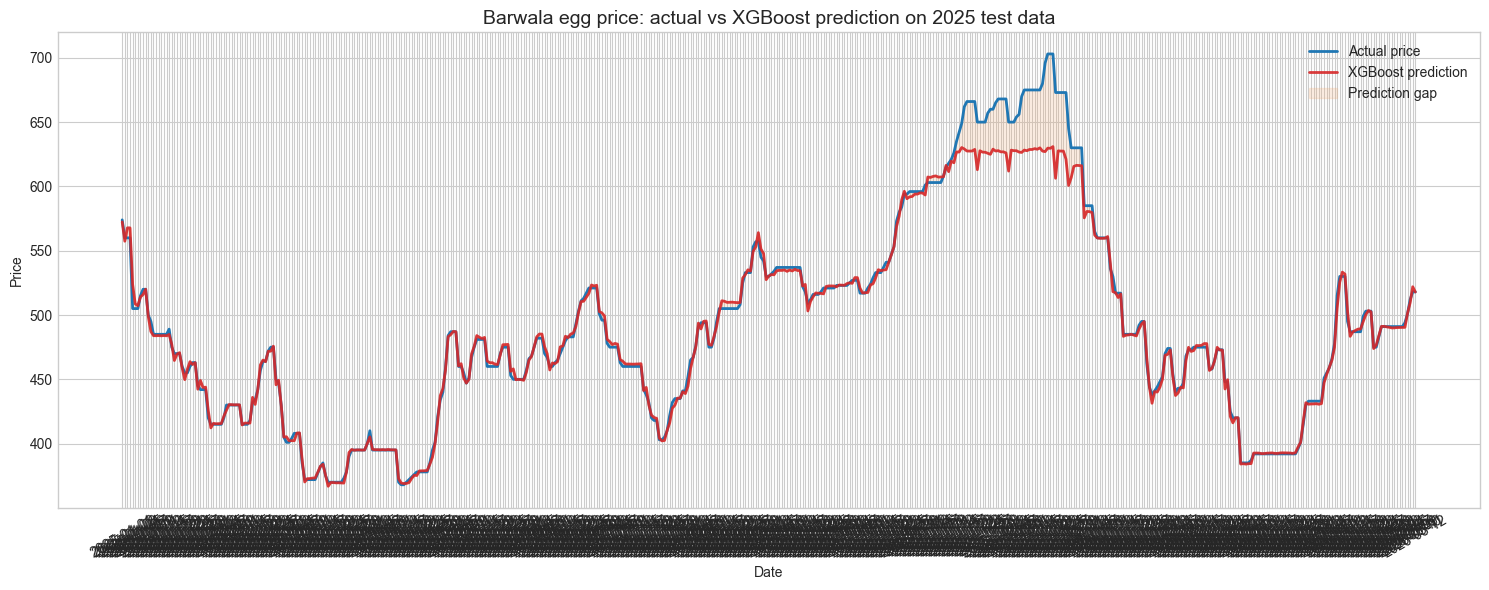

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(test_results["Date"], test_results[target], label="Actual price", color="#1f77b4", linewidth=2)
ax.plot(test_results["Date"], test_results["Predicted_Price"], label="XGBoost prediction", color="#d62728", linewidth=2, alpha=0.9)
ax.fill_between(
    test_results["Date"],
    test_results[target],
    test_results["Predicted_Price"],
    color="#f4a261",
    alpha=0.18,
    label="Prediction gap"
)

ax.set_title("Barwala egg price: actual vs XGBoost prediction on 2025 test data", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
best_model.feature_importances_

array([1.6103864e-02, 9.7971845e-01, 2.4961503e-04, 1.8986819e-04,
       1.8402067e-04, 1.4772592e-04, 1.6715217e-03, 1.5182931e-04,
       2.9760448e-04, 1.2931699e-04, 3.1450376e-04, 1.1028379e-04,
       5.3796964e-04, 1.6467291e-04, 0.0000000e+00, 0.0000000e+00,
       2.8695158e-05], dtype=float32)

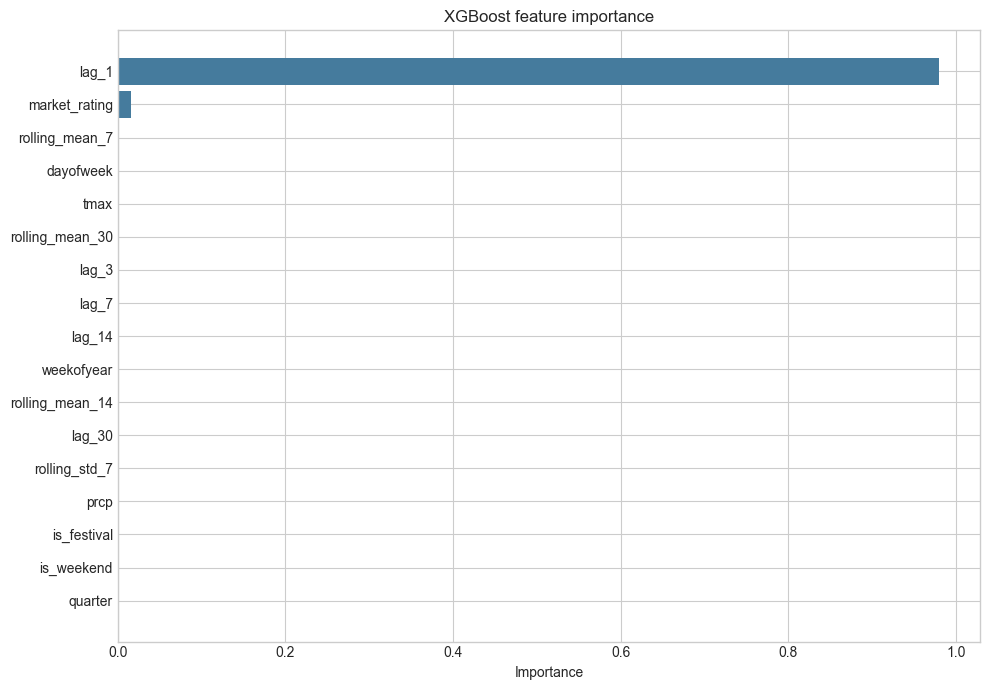

,Feature,Importance
1,lag_1,0.979718
0,market_rating,0.016104
6,rolling_mean_7,0.001672
12,dayofweek,0.000538
10,tmax,0.000315
8,rolling_mean_30,0.000298
2,lag_3,0.000250
3,lag_7,0.000190
4,lag_14,0.000184
13,weekofyear,0.000165


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features_train,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feature_importance["Feature"], feature_importance["Importance"], color="#457b9d")
ax.set_title("XGBoost feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

feature_importance.sort_values("Importance", ascending=False).head(10)


In [ ]:
test_results.head()

,Date,Price,Predicted_Price,Error,Absolute_Error
3119,2025-01-01,574.0,572.388367,1.611633,1.611633
3120,2025-01-02,560.0,557.385498,2.614502,2.614502
3121,2025-01-03,560.0,567.782715,-7.782715,7.782715
3122,2025-01-04,560.0,567.782715,-7.782715,7.782715
3123,2025-01-05,505.0,523.832336,-18.832336,18.832336


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Actual price line
fig.add_trace(
    go.Scatter(
        x=test_results["Date"],
        y=test_results[target],
        mode="lines",
        name="Actual price",
        line=dict(color="#1f77b4", width=2)
    )
)

# Predicted price line
fig.add_trace(
    go.Scatter(
        x=test_results["Date"],
        y=test_results["Predicted_Price"],
        mode="lines",
        name="XGBoost prediction",
        line=dict(color="#d62728", width=2)
    )
)

# Prediction gap fill
fig.add_trace(
    go.Scatter(
        x=pd.concat([test_results["Date"], test_results["Date"][::-1]]),
        y=pd.concat([test_results[target], test_results["Predicted_Price"][::-1]]),
        fill='toself',
        fillcolor='rgba(244, 162, 97, 0.18)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name="Prediction gap"
    )
)

# Layout
fig.update_layout(
    title="Barwala egg price: actual vs XGBoost prediction on 2025 test data",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white",
    height=500,
    width=1200,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=30)

# Show plot
fig.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Create figure
fig = go.Figure()

# Actual price
fig.add_trace(
    go.Scatter(
        x=test_results["Date"],
        y=test_results[target],
        mode="lines",
        name="Actual price",
        line=dict(color="#1f77b4", width=2)
    )
)

# Predicted price
fig.add_trace(
    go.Scatter(
        x=test_results["Date"],
        y=test_results["Predicted_Price"],
        mode="lines",
        name="XGBoost prediction",
        line=dict(color="#d62728", width=2)
    )
)

# Gap fill
fig.add_trace(
    go.Scatter(
        x=pd.concat([test_results["Date"], test_results["Date"][::-1]]),
        y=pd.concat([test_results[target], test_results["Predicted_Price"][::-1]]),
        fill='toself',
        fillcolor='rgba(244,162,97,0.18)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name="Prediction gap"
    )
)

# Layout
fig.update_layout(
    title="Barwala egg price: actual vs XGBoost prediction on 2025 test data",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white",
    height=500,
    width=1200
)

# Open directly in browser
fig.show(renderer="browser")

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Ensure Date column is datetime
test_results["Date"] = pd.to_datetime(test_results["Date"])

# Create month column
test_results["Month"] = test_results["Date"].dt.strftime("%Y-%m")

# Monthly aggregation
monthly_data = (
    test_results
    .groupby("Month")
    .agg({
        target: "mean",
        "Predicted_Price": "mean"
    })
    .reset_index()
)

# Round values
monthly_data[target] = monthly_data[target].round(2)
monthly_data["Predicted_Price"] = monthly_data["Predicted_Price"].round(2)

# Create figure
fig = go.Figure()

# Actual price line
fig.add_trace(
    go.Scatter(
        x=monthly_data["Month"],
        y=monthly_data[target],
        mode="lines+markers+text",
        name="Actual price",
        text=monthly_data[target],
        textposition="top center",
        line=dict(color="#1f77b4", width=3),
        marker=dict(size=8)
    )
)

# Predicted price line
fig.add_trace(
    go.Scatter(
        x=monthly_data["Month"],
        y=monthly_data["Predicted_Price"],
        mode="lines+markers+text",
        name="Predicted price",
        text=monthly_data["Predicted_Price"],
        textposition="bottom center",
        line=dict(color="#d62728", width=3),
        marker=dict(size=8)
    )
)

# Layout
fig.update_layout(
    title="Monthly Barwala Egg Price: Actual vs Predicted",
    xaxis_title="Month",
    yaxis_title="Price",
    template="plotly_white",
    height=600,
    width=1300,
    hovermode="x unified"
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=45)

# Open in browser
fig.write_html("monthly_egg_price_prediction.html", auto_open=True)

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Ensure datetime format
test_results["Date"] = pd.to_datetime(test_results["Date"])

# Create month column
test_results["Month"] = test_results["Date"].dt.strftime("%Y-%m")

# Select month you want to visualize
selected_month = "2025-03"

# Filter selected month data
month_data = test_results[
    test_results["Month"] == selected_month
].copy()

# Create day column
month_data["Day"] = month_data["Date"].dt.day

# Round values
month_data[target] = month_data[target].round(2)
month_data["Predicted_Price"] = month_data["Predicted_Price"].round(2)

# Create figure
fig = go.Figure()

# Actual price
fig.add_trace(
    go.Scatter(
        x=month_data["Day"],
        y=month_data[target],
        mode="lines+markers+text",
        name="Actual Price",
        text=month_data[target],
        textposition="top center",
        line=dict(color="#1f77b4", width=3),
        marker=dict(size=8)
    )
)

# Predicted price
fig.add_trace(
    go.Scatter(
        x=month_data["Day"],
        y=month_data["Predicted_Price"],
        mode="lines+markers+text",
        name="Predicted Price",
        text=month_data["Predicted_Price"],
        textposition="bottom center",
        line=dict(color="#d62728", width=3),
        marker=dict(size=8)
    )
)

# Layout
fig.update_layout(
    title=f"Daily Egg Prices - {selected_month}",
    xaxis_title="Day of Month",
    yaxis_title="Price",
    template="plotly_white",
    height=700,
    width=1400,
    hovermode="x unified"
)

# Better x-axis formatting
fig.update_xaxes(
    tickmode="linear",
    dtick=1
)

# Open in browser
fig.write_html(
    f"daily_price_{selected_month}.html",
    auto_open=True
)